<h1 align="center">Классификация токсичных комментариев для сервиса Викишоп с помощью BERT</h1>

Данный проект посвящён анализу пользовательских комментариев в интернет-магазине «Викишоп» с целью выявления токсичных высказываний.

Цель работы: разработать модель машинного обучения, которая позволит классифицировать комментарии на токсичные и нетоксичные.

План работы:

* Обзор данных: загрузка и исследовательский анализ текстов комментариев;
* Подготовка выборки: очистка текста, преобразование данных и формирование обучающей и тестовой частей;
* Обучение моделей: сравнение baseline-моделей (TF-IDF + классические алгоритмы) и нейросетевого подхода на основе BERT;
* Анализ результатов: оценка качества моделей по метрике F1 и выбор оптимального решения.

Описание данных:

* toxic\_comments.csv - датасет с комментариями пользователей;
  * 'text' - текст комментария;
  * 'toxic' - целевой признак.

## Обзор данных

### Загрузка и изучение данных

In [1]:
# Стандартные библиотеки
import os
import re
import warnings
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
from nltk import pos_tag
from nltk.tokenize import word_tokenize

# Загрузка ресурсов NLTK
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Работа с данными
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Модели и обработка текста
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix
)

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader

# Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup
)
from transformers.utils import logging as hf_logging

# Настройка окружения и предупреждений
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

hf_logging.set_verbosity_error()

try:
    from huggingface_hub.utils import logging as hub_logging
    hub_logging.set_verbosity_error()
except Exception:
    pass

In [2]:
# Загрузка данных
comments_df = pd.read_csv('/datasets/toxic_comments.csv', index_col=0)

In [3]:
# Функция для проверки пропусков
def check_missing_values(df):
    nan_df = pd.DataFrame({
        'nan_qty': df.isna().sum(),
        'nan_percent': (df.isna().mean() * 100).round(2)
    }).sort_values(by='nan_qty', ascending=False)

    if int(nan_df['nan_qty'].sum()) == 0:
        print("Пропусков в данных не обнаружено")
    else:
        display(nan_df[nan_df['nan_qty'] > 0].style.format({'nan_percent': '{:.2f}%'}))

# Функция для определения длины текстов
def show_text_length_plots(lengths, title_prefix="Длина текста"):
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(lengths, bins=50, ax=ax)
    ax.set_title(f"{title_prefix}: распределение по символам")
    ax.set_xlabel("Длина (символы)")
    ax.set_ylabel("Количество")
    plt.tight_layout()
    plt.show()

# Функция для обзора данных
def data_overview_text(
    df: pd.DataFrame,
    text_col: str = 'text',
    target_col: str | None = 'toxic',
    show_examples: bool = True,
):
    # Общая информация
    mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
    print(f"Размер данных: {df.shape[0]} строк × {df.shape[1]} столбцов")

    print("\nПервые 3 строки:")
    display(df.head(3))

    print("\nИнформация о данных:")
    print("----------------------------------------")
    df.info()

    # Пропуски
    print("\nПроверка пропусков")
    print("----------------------------------------")
    check_missing_values(df)

    # Дубликаты
    print("\nПроверка явных дубликатов строк (полных):")
    dups_all = df.duplicated().sum()
    print(f"Количество полных дубликатов: {dups_all}")
    if text_col in df.columns:
        print("Проверка дубликатов по полю текста:")
        dups_text = df.duplicated(subset=[text_col]).sum()
        uniq_texts = df[text_col].nunique(dropna=False)
        print(f"- Дубликаты по тексту: {dups_text}")
        print(f"- Уникальных текстов: {uniq_texts}")

    # Баланс классов
    if target_col and target_col in df.columns:
        print(f"\nБаланс классов по `{target_col}`:")
        vc = df[target_col].value_counts(dropna=False)
        display(pd.DataFrame({
            'count': vc,
            'share_%': (vc / vc.sum() * 100).round(2)
        }))

    # Статистика длин текстов
    if text_col in df.columns:
        s = df[text_col].astype(str)
        lengths = s.str.len()
        print("\nСтатистика длины текстов (символы):")
        display(lengths.describe(percentiles=[.1, .25, .5, .75, .9, .95]).round(2))

        # Гистограмма длин
        show_text_length_plots(lengths)

Размер данных: 159292 строк × 2 столбцов

Первые 3 строки:


,text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0



Информация о данных:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 159292 entries, 0 to 159450
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.6+ MB

Проверка пропусков
----------------------------------------
Пропусков в данных не обнаружено

Проверка явных дубликатов строк (полных):
Количество полных дубликатов: 0
Проверка дубликатов по полю текста:
- Дубликаты по тексту: 0
- Уникальных текстов: 159292

Баланс классов по `toxic`:


,count,share_%
toxic,,
0,143106,89.84
1,16186,10.16



Статистика длины текстов (символы):


count    159292.00
mean        393.69
std         590.11
min           5.00
10%          47.00
25%          95.00
50%         205.00
75%         435.00
90%         889.00
95%        1354.00
max        5000.00
Name: text, dtype: float64

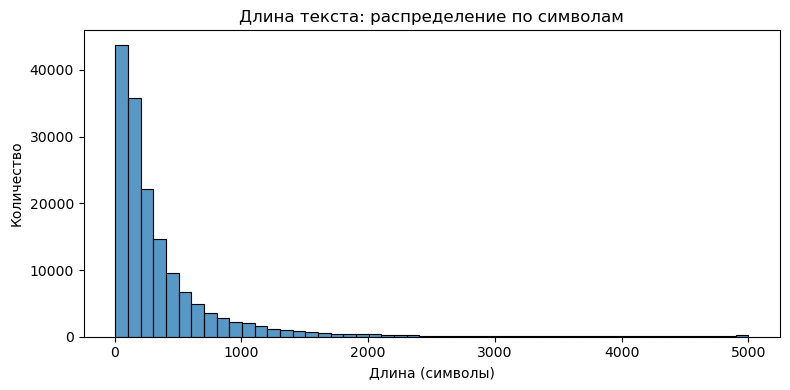

In [4]:
data_overview_text(comments_df, text_col='text', target_col='toxic')

### Промежуточные выводы после обзора данных

* Датасет содержит 159 292 строки и 2 столбца ('text', 'toxic');
* Пропусков и явных дубликатов (как полных строк, так и по тексту) не обнаружено;
* Данные несбалансированы, токсичных комментариев значительно меньше;
* Большинство комментариев короткие (до 500 символов), но есть и очень длинные (максимум 5000 символов).

## Обучение моделей

In [5]:
# Предобработка с POS-лемматизацией
wnl = WordNetLemmatizer()

def normalize_text(s: pd.Series) -> pd.Series:
    s = s.astype(str)
    s = s.str.replace(r'\s+', ' ', regex=True)
    s = s.str.strip()
    s = s.str.replace(r'["“”‘’`´]', '', regex=True)
    s = s.str.lower()
    return s

def _treebank_to_wordnet(tag: str):
    if not tag:
        return wn.NOUN
    if tag.startswith('J'):
        return wn.ADJ
    if tag.startswith('V'):
        return wn.VERB
    if tag.startswith('N'):
        return wn.NOUN
    if tag.startswith('R'):
        return wn.ADV
    return wn.NOUN

def lemmatize_text_pos(s: pd.Series) -> pd.Series:
    lemmas_series = []
    for txt in s:
        tokens = word_tokenize(txt)
        tb_tags = pos_tag(tokens)
        lemmas = []
        for tok, tb in tb_tags:
            wn_pos = _treebank_to_wordnet(tb)
            if any(c.isalpha() for c in tok):
                lemmas.append(wnl.lemmatize(tok.lower(), wn_pos))
        lemmas_series.append(" ".join(lemmas))
    return pd.Series(lemmas_series, index=s.index)

df = comments_df.copy()
df['text_raw'] = df['text']
df['text'] = normalize_text(df['text'])
df = df[df['text'].str.len() > 0].reset_index(drop=True)

# Лемматизация с POS
df['text_lemma'] = lemmatize_text_pos(df['text'])

X_base = df['text_lemma']
X_bert = df['text_raw']
y = df['toxic'].astype(int)

Xb_train, Xb_temp, y_train, y_temp = train_test_split(
    X_base, y, test_size=0.2, stratify=y, random_state=42
)
Xb_valid, Xb_test, y_valid, y_test = train_test_split(
    Xb_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

Xbert_train, Xbert_temp, yb_train, yb_temp = train_test_split(
    X_bert, y, test_size=0.2, stratify=y, random_state=42
)
Xbert_valid, Xbert_test, yb_valid, yb_test = train_test_split(
    Xbert_temp, yb_temp, test_size=0.5, stratify=yb_temp, random_state=42
)

In [6]:
# Бейзлайн TF-IDF
tfidf_params = dict(ngram_range=(1, 2), min_df=5, max_df=0.95, sublinear_tf=True)

# LinearSVC
svc_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(**tfidf_params)),
    ('clf', LinearSVC(class_weight='balanced'))
])
svc_pipe.fit(Xb_train, y_train)
pred_valid_svc = svc_pipe.predict(Xb_valid)
f1_valid_svc = f1_score(y_valid, pred_valid_svc)
print(f'LinearSVC valid F1: {f1_valid_svc:.4f}')

# Logistic Regression
lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(**tfidf_params)),
    ('clf', LogisticRegression(max_iter=2000, n_jobs=-1, class_weight='balanced'))
])
lr_pipe.fit(Xb_train, y_train)

proba_valid_lr = lr_pipe.predict_proba(Xb_valid)[:, 1]
best_f1_lr, best_t_lr = 0.0, 0.5
for t in np.linspace(0.2, 0.8, 25):
    f1_t = f1_score(y_valid, (proba_valid_lr >= t).astype(int))
    if f1_t > best_f1_lr:
        best_f1_lr, best_t_lr = f1_t, t
f1_valid_lr = best_f1_lr
print(f'LogReg valid F1: {f1_valid_lr:.4f}')

LinearSVC valid F1: 0.7952
LogReg valid F1: 0.7913


In [7]:
# BERT
# Гиперпараметры
MODEL_NAME = "prajjwal1/bert-tiny"
MAX_LEN = 96
EPOCHS_FROZEN   = 2
EPOCHS_UNFROZEN = 1
BATCH_SIZE = 16
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TextDS(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = tokenizer(self.texts[i], truncation=True, max_length=MAX_LEN)
        enc["labels"] = int(self.labels[i])
        return enc

train_ds = TextDS(Xbert_train, yb_train)
val_ds   = TextDS(Xbert_valid, yb_valid)
test_ds  = TextDS(Xbert_test,  yb_test)

collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8 if torch.cuda.is_available() else None)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collator)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)

# Модель
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

# Loss
loss_fn = torch.nn.CrossEntropyLoss()

def make_opt_sched(params, lr, total_steps: int):
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=0.01)
    warmup = max(1, int(0.06 * total_steps))
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup, num_training_steps=total_steps)
    return optimizer, scheduler

def run_epoch(dl, train=False, optimizer=None, scheduler=None):
    if train: model.train()
    else: model.eval()
    total_loss, preds_all, labels_all, proba_all = 0.0, [], [], []
    for batch in dl:
        labels = batch.pop("labels")
        labels = labels.to(device) if torch.is_tensor(labels) else torch.tensor(labels, dtype=torch.long, device=device)
        batch = {k: v.to(device) for k,v in batch.items()}

        if train: optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train):
            out = model(**batch)
            loss = loss_fn(out.logits, labels)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                if scheduler: scheduler.step()
        total_loss += loss.item()

        probs = torch.softmax(out.logits, dim=-1)[:,1].detach().cpu().numpy()
        proba_all.extend(probs)
        preds_all.extend((probs >= 0.5).astype(int))
        labels_all.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dl)
    acc = accuracy_score(labels_all, preds_all)
    p, r, f1, _ = precision_recall_fscore_support(labels_all, preds_all, average='binary', zero_division=0)
    return avg_loss, acc, p, r, f1, np.array(proba_all), np.array(labels_all)

for p in model.base_model.parameters():
    p.requires_grad = False

head_params = list(model.classifier.parameters())
opt, sch = make_opt_sched(head_params, lr=1e-3, total_steps=len(train_dl)*EPOCHS_FROZEN)

for ep in range(EPOCHS_FROZEN):
    tr = run_epoch(train_dl, train=True, optimizer=opt, scheduler=sch)
    va = run_epoch(val_dl)
    print(f"[Frozen {ep+1}] train F1={tr[4]:.4f} | valid F1={va[4]:.4f}")

for p in model.base_model.parameters():
    p.requires_grad = True

base_params = [p for n,p in model.named_parameters() if not n.startswith("classifier.")]
params = [{'params': head_params, 'lr': 5e-4},
          {'params': base_params, 'lr': 2e-5}]
opt, sch = make_opt_sched(params, lr=2e-5, total_steps=len(train_dl)*EPOCHS_UNFROZEN)

for ep in range(EPOCHS_UNFROZEN):
    tr = run_epoch(train_dl, train=True, optimizer=opt, scheduler=sch)
    va = run_epoch(val_dl)
    print(f"[Unfrozen {ep+1}] train F1={tr[4]:.4f} | valid F1={va[4]:.4f}")

f1_valid_bert_default = va[4]

val_proba_bert_final, val_labels_bert_final = va[5], va[6]
best_f1_bert, best_t_bert = 0.0, 0.5
for t in np.linspace(0.2, 0.8, 25):
    f1_t = f1_score(val_labels_bert_final, (val_proba_bert_final >= t).astype(int))
    if f1_t > best_f1_bert:
        best_f1_bert, best_t_bert = f1_t, t

f1_valid_bert = best_f1_bert
print(f"Final valid F1 for BERT = {f1_valid_bert:.4f}")

test = run_epoch(test_dl)
test_proba_bert, test_labels_bert = test[5], test[6]
test_pred_bert = (test_proba_bert >= best_t_bert).astype(int)
acc_bert = accuracy_score(test_labels_bert, test_pred_bert)
prec_bert = precision_score(test_labels_bert, test_pred_bert)
rec_bert  = recall_score(test_labels_bert, test_pred_bert)
f1_bert   = f1_score(test_labels_bert, test_pred_bert)
metrics_bert = pd.DataFrame({
    "Model": ["BERT"],
    "Accuracy": [round(acc_bert, 4)],
    "Precision": [round(prec_bert, 4)],
    "Recall": [round(rec_bert, 4)],
    "F1-score": [round(f1_bert, 4)]
})
display(metrics_bert)

[Frozen 1] train F1=0.2166 | valid F1=0.3471
[Frozen 2] train F1=0.2942 | valid F1=0.2719
[Unfrozen 1] train F1=0.7041 | valid F1=0.7727
Final valid F1 for BERT = 0.7810


,Model,Accuracy,Precision,Recall,F1-score
0,BERT,0.9571,0.8502,0.7011,0.7684


### Сравнение моделей

,Model,F1_valid
0,LinearSVC,0.7952
1,LogReg,0.7913
2,BERT,0.7810



Лучшая модель по валидации (F1): LinearSVC

Метрики лучшей модели на тесте:


,Model,Accuracy,Precision,Recall,F1-score
0,LinearSVC,0.9574,0.7916,0.7881,0.7898


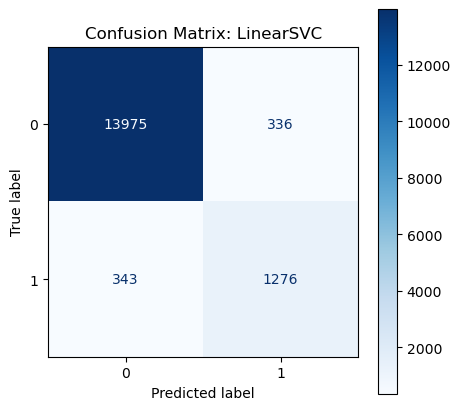

In [8]:
# Сравнение моделей
val_table = pd.DataFrame({
    "Model":   ["LinearSVC", "LogReg", "BERT"],
    "F1_valid": [round(f1_valid_svc, 4),
                 round(f1_valid_lr,  4),
                 round(f1_valid_bert,4)]
})
display(val_table)

best_model_name = val_table.loc[val_table["F1_valid"].idxmax(), "Model"]
print(f"\nЛучшая модель по валидации (F1): {best_model_name}")

# Оценка на тесте
if best_model_name == "LinearSVC":
    y_true_test = y_test
    y_pred_test = svc_pipe.predict(Xb_test)

elif best_model_name == "LogReg":
    y_true_test = y_test
    proba_test_lr = lr_pipe.predict_proba(Xb_test)[:, 1]
    y_pred_test = (proba_test_lr >= best_t_lr).astype(int)

else:
    y_true_test = test_labels_bert
    y_pred_test = (test_proba_bert >= best_t_bert).astype(int)

# Метрики лучшей модели на тесте
acc = accuracy_score(y_true_test, y_pred_test)
prec = precision_score(y_true_test, y_pred_test)
rec  = recall_score(y_true_test, y_pred_test)
f1   = f1_score(y_true_test, y_pred_test)

best_test_df = pd.DataFrame({
    "Model":     [best_model_name],
    "Accuracy":  [round(acc, 4)],
    "Precision": [round(prec, 4)],
    "Recall":    [round(rec, 4)],
    "F1-score":  [round(f1, 4)]
})
print("\nМетрики лучшей модели на тесте:")
display(best_test_df)

# Confusion Matrix
cm = confusion_matrix(y_true_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap="Blues", values_format='d', ax=ax, colorbar=True)
ax.set_title(f"Confusion Matrix: {best_model_name}", fontsize=12)
plt.show()

### Промежуточные выводы после обучения моделей

* LinearSVC
  * На валидационной выборке показал F1 = 0.7952;
  * На тестовой выборке итоговый F1 составил 0.7898, что является наилучшим результатом среди всех моделей;

* Logistic Regression
  * На валидации достигла F1 = 0.7913 при оптимальном подборе порога.

* BERT
  * После дообучения энкодера качество на валидации составило F1 = 0.7810;
  * На тестовой выборке итоговый F1 оказался 0.7684, что соответствует целевым требованиям, но уступает LinearSVC;

* Сравнение моделей
  * Модели сравнивались по метрике F1 на отложенной валидационной выборке. Порог для вероятностных моделей (LogReg, BERT) подбирался только на валидации. На тестовой выборке метрики посчитаны только для лучшей модели, выбранной по наивысшему F1 на валидации;
  * Классическая модель LinearSVC оказалась лучшей по F1 на тесте (0.7898), при этом обучалась значительно быстрее и потребовала меньше вычислительных ресурсов;
  * BERT показал более низкий результат, но подтвердил способность учитывать семантические связи в тексте.

## Выводы

* В рамках проекта проведена классификация токсичных комментариев для сервиса "Викишоп" на основе датасета с \~160 тыс. записей;
* Данные оказались чистыми: пропусков и дубликатов не выявлено; распределение классов несбалансированное (токсичных комментариев \~10%);
* Для построения моделей были протестированы два подхода:
  * Baseline на основе TF-IDF + классические алгоритмы:
    * LinearSVC показал наилучший результат среди классических методов (F1 = 0.7952 на валидации и 0.7898 на тесте);
    * Logistic Regression достигла F1 = 0.7913 на валидации;
  * Нейросетевой подход (BERT, bert-tiny):
    * После дообучения модель показала F1 = 0.7810 на валидации и 0.7684 на тесте;
    * Качество оказалось сопоставимым с LinearSVC, но обучение заняло больше времени и потребовало больших вычислительных ресурсов;
* Классические модели (особенно LinearSVC) продемонстрировали чуть более высокое качество при значительно меньших вычислительных затратах;
* Использование BERT имеет смысл при дальнейшем масштабировании задачи (например, при работе с более сложной лексикой или переносе на другие языки/домены), однако для текущего кейса LinearSVC остаётся оптимальным выбором.